In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/givendata/PastLoans.csv
/kaggle/input/givendata/NewApplications_Lender1_Round1.csv


# EDA (simple version)

In [2]:
import pandas as pd


past_loans_path = "/kaggle/input/givendata/PastLoans.csv"
new_apps_path = "/kaggle/input/givendata/NewApplications_Lender1_Round1.csv"


past_loans = pd.read_csv(past_loans_path)
new_apps = pd.read_csv(new_apps_path)


print("=== PastLoans.csv ===")
print(past_loans.shape)
print(past_loans.columns)
print(past_loans.head())
print("\n Nah values: ")
print(past_loans.isnull().sum())

print("\n" + "="*50 + "\n")

print("=== NewApplications_Lender1_Round1.csv ===")
print(new_apps.shape)
print(new_apps.columns)
print(new_apps.head())
print("\n Nah values: ")
print(new_apps.isnull().sum())

print("\n--- PastLoans info() ---")
past_loans.info()

print("\n--- NewApplications info() ---")
new_apps.info()


=== PastLoans.csv ===
(100000, 8)
Index(['sex', 'employment', 'married', 'income', 'signal1', 'signal2',
       'signal3', 'default'],
      dtype='object')
  sex  employment  married  income   signal1   signal2   signal3  default
0   M  unemployed        0       0  0.749267  0.422656  0.738735        0
1   M    employed        1   26108  0.697428  0.596361  0.733947        0
2   M    employed        1   11810  0.000000  0.652496  0.000000        0
3   M  unemployed        1       0  0.000000  0.000000  0.000000        0
4   F     retired        1    6310  0.000000  0.041123  0.203202        0

 Nah values: 
sex           0
employment    0
married       0
income        0
signal1       0
signal2       0
signal3       0
default       0
dtype: int64


=== NewApplications_Lender1_Round1.csv ===
(100000, 6)
Index(['id', 'sex', 'employment', 'married', 'income', 'signal1'], dtype='object')
   id sex employment  married  income   signal1
0   1   M   employed        0   29758  0.765355
1   2  

# Baseline Model

In [3]:
# === Lending Game: Lender 1 – Part 1 (Train PD model + Make Offers + EPPA KPI) ===
# Paths (as you provided)
PAST_LOANS_PATH = "/kaggle/input/givendata/PastLoans.csv"
NEW_APPS_PATH   = "/kaggle/input/givendata/NewApplications_Lender1_Round1.csv"
OUT_PATH        = "/kaggle/working/LoanOffers_Lender1_Round1.csv"

# -----------------------------
# 1) Imports & basic settings
# -----------------------------
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -----------------------------
# 2) Load data
# -----------------------------
past = pd.read_csv(PAST_LOANS_PATH)
apps = pd.read_csv(NEW_APPS_PATH)


# Safety: ensure expected columns exist
expected_train_cols = {'sex','employment','married','income','signal1','default'}
missing_cols = expected_train_cols - set(past.columns)
if missing_cols:
    raise ValueError(f"PastLoans.csv is missing columns: {missing_cols}")

# Use only features visible to Lender 1 at prediction time
FEATURES = ['sex','employment','married','income','signal1']
TARGET   = 'default'

# -----------------------------
# 3) Basic cleaning (lightweight, safe)
# -----------------------------
# Minimal NaN handling and type casting for training data
for col in FEATURES:
    if past[col].dtype.kind in "biufc":
        past[col] = past[col].astype(float)
        past[col] = past[col].fillna(past[col].median())
    else:
        past[col] = past[col].astype(str).fillna("missing")

# Clip income outliers (robustness)
if 'income' in FEATURES:
    past['income'] = past['income'].clip(lower=0, upper=past['income'].quantile(0.999))

# Mirror cleaning for new applications using training medians
for col in FEATURES:
    if apps[col].dtype.kind in "biufc":
        apps[col] = apps[col].astype(float)
        apps[col] = apps[col].fillna(past[col].median())

    else:
        apps[col] = apps[col].astype(str).fillna("missing")

if 'income' in FEATURES:
    apps['income'] = apps['income'].clip(lower=0, upper=past['income'].quantile(0.999))

# -----------------------------
# 4) Train/valid split (to check performance)
# -----------------------------
X = past[FEATURES].copy()
y = past[TARGET].astype(int).values

cat_cols = [c for c in FEATURES if X[c].dtype == 'object']
num_cols = [c for c in FEATURES if c not in cat_cols]

# Column-wise preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ],
    remainder='drop'
)


# Base classifier (logistic), use class_weight to handle class imbalance
base_clf = LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs')

# Calibrated pipeline for well-aligned probabilities
clf = Pipeline(steps=[
    ('prep', preprocess),
    ('cal', CalibratedClassifierCV(base_estimator=base_clf, method='isotonic', cv=5))
])

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

clf.fit(X_tr, y_tr)

# Validation metrics (AUC and Brier)
pd_va = clf.predict_proba(X_va)[:, 1]
auc_va = roc_auc_score(y_va, pd_va)
brier_va = brier_score_loss(y_va, pd_va)
print(f"[Validation] AUC = {auc_va:.4f} | Brier = {brier_va:.4f}")

# -----------------------------
# 5) Refit on full train (recommended before final scoring)
# -----------------------------
clf.fit(X, y)

# -----------------------------
# 6) Predict PD on new applications
# -----------------------------
if 'applicant_id' not in apps.columns:
    # Create a stable ID if not provided
    apps['applicant_id'] = np.arange(1, len(apps)+1)

pd_pred = clf.predict_proba(apps[FEATURES])[:, 1]
apps['PD'] = pd_pred

/usr/local/lib/python3.11/dist-packages/sklearn/calibration.py:321: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


[Validation] AUC = 0.7250 | Brier = 0.0843


/usr/local/lib/python3.11/dist-packages/sklearn/calibration.py:321: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


# Pricing Strategy Test

**Pricing Version 1: break-even + margin + fixed preference cushion + rejection**

In [4]:
# -----------------------------
# 7) Pricing rule: break-even + margin + preference cushion + rejection
# -----------------------------
def make_offer_rate(pd_value,
                    c0=0.02, c1=0.10,            # base margin + risk premium
                    pd_reject=0.60,               # reject threshold on PD
                    eps=0.00,                     # tiny randomization (0.00~0.02)
                    pref_delta=0.02,              # market rule: 2% buyer preference
                    pref_prob=1/3,                # about one third prefer us
                    kappa=0.4                     # portion of cushion we "take"
                   ):
    """
    Return an offer rate for a given PD.
    - Reject (return np.inf) if PD exceeds pd_reject.
    - Base price: r_break = PD / (1 - PD) (break-even)
    - Margin: c0 + c1 * PD
    
    - Preference cushion: we eat a portion of the 2% advantage for likely fans,
      scaled by (1 - PD) so that low-risk borrowers get more cushion.
    """
    if pd_value >= pd_reject:
        return np.inf

    r_break = pd_value / (1 - pd_value + 1e-12)
    margin  = c0 + c1 * pd_value
    pref_cushion = kappa * pref_prob * pref_delta * (1 - pd_value)

    r = r_break + margin + pref_cushion

    if eps > 0:
        r *= (1 + np.random.uniform(-eps, eps))
    return r

# Vectorize pricing
apps['offer_rate'] = apps['PD'].apply(make_offer_rate)

# Safety: guard against negative/absurd values (shouldn't happen)
apps.loc[apps['offer_rate'] < 0, 'offer_rate'] = 0.0

# -----------------------------
# 8) Save offers
# -----------------------------
offers = apps[['applicant_id', 'offer_rate']].copy()
offers.to_csv(OUT_PATH, index=False)
print(f"Saved offers to: {OUT_PATH}")

# -----------------------------
# 9) Quick summary
# -----------------------------
n_total = len(offers)
n_reject = np.isinf(offers['offer_rate']).sum()
print(f"Total applicants: {n_total}")
print(f"Rejected (no offer): {n_reject} ({n_reject/n_total:.2%})")
print("Sample rows:")
print(offers.head(10))

Saved offers to: /kaggle/working/LoanOffers_Lender1_Round1.csv
Total applicants: 100000
Rejected (no offer): 0 (0.00%)
Sample rows:
   applicant_id  offer_rate
0             1    0.042185
1             2    0.146839
2             3    0.044368
3             4    0.114091
4             5    0.153031
5             6    0.206652
6             7    0.039847
7             8    0.492252
8             9    0.044138
9            10    0.180463


**Estimation Version 1: EPPA under different marketing style**

In [5]:
# 10) EPPA: Expected Profit per Applicant (single KPI for pricing)
# =====================================================================
# We evaluate pricing under a fixed market simulation protocol:
# - Each applicant prefers one lender (us/A/B) with equal probability (1/3).
# - Preference reduces the *effective* rate by 2% for the preferred lender.
# - Two competitors price using break-even + margin + rejection on *their* PD
#   (unknown to us). We approximate competitors' PD by adding Gaussian noise
#   to our PD and clipping to [0.001, 0.999].
# - The lowest effective rate wins. If we reject (inf), we cannot win.
# - Our expected profit on a won deal is: (1 - PD)*L*r - PD*L.
# - Our KPI EPPA is the mean expected profit across all applicants
#   (non-wins contribute zero).
L = 10_000.0  # principal

def competitor_pricer_from_pd(pd_series, c0=0.02, c1=0.10, pd_reject=0.60):
    """Competitor pricing rule: break-even + margin; reject with inf if PD >= threshold."""
    r_break = pd_series / (1.0 - pd_series)
    margin = c0 + c1 * pd_series
    r = r_break + margin
    r = np.where(pd_series >= pd_reject, np.inf, r)
    return r

def _evaluate_core(df_apps, my_pricer, pd_col, seed, compA_params, compB_params, pref_bonus):
    """
    Core evaluator used by all scenarios. Returns (eppa, summary_dict).
    All arguments are explicit so scenarios differ only by comp* params.
    """
    rng = np.random.default_rng(seed)
    df = df_apps.copy()

    # 1) Borrower preference: 1=us, 2=compA, 3=compB (equal mass)
    n = len(df)
    df['borrower_type'] = rng.integers(low=1, high=4, size=n)

    # 2) Competitor PDs via noisy approximation of our PD
    base_pd = df[pd_col].to_numpy().astype(float)

    def noisy_pd(base, sd):
        pd_hat = base + rng.normal(0.0, sd, size=base.shape)
        return np.clip(pd_hat, 0.001, 0.999)

    df['PD_compA'] = noisy_pd(base_pd, compA_params.get('noise_sd', 0.06))
    df['PD_compB'] = noisy_pd(base_pd, compB_params.get('noise_sd', 0.06))

    # 3) Our offer
    my_rates = np.array([my_pricer(p) for p in base_pd])
    df['offer_me'] = my_rates

    # 4) Competitors' offers
    offer_A = competitor_pricer_from_pd(
        df['PD_compA'].values,
        c0=compA_params['c0'], c1=compA_params['c1'], pd_reject=compA_params['pd_reject']
    )
    offer_B = competitor_pricer_from_pd(
        df['PD_compB'].values,
        c0=compB_params['c0'], c1=compB_params['c1'], pd_reject=compB_params['pd_reject']
    )
    df['offer_A'] = offer_A
    df['offer_B'] = offer_B

    # 5) Preference-adjusted effective rates
    eff_me = df['offer_me'].to_numpy().copy()
    eff_A  = df['offer_A'].to_numpy().copy()
    eff_B  = df['offer_B'].to_numpy().copy()

    eff_me = np.where(df['borrower_type'].to_numpy()==1, eff_me - pref_bonus, eff_me)
    eff_A  = np.where(df['borrower_type'].to_numpy()==2, eff_A  - pref_bonus, eff_A)
    eff_B  = np.where(df['borrower_type'].to_numpy()==3, eff_B  - pref_bonus, eff_B)

    # 6) Winner selection (min effective rate). 0=us, 1=A, 2=B
    eff_stack  = np.vstack([eff_me, eff_A, eff_B]).T
    winner_idx = np.argmin(eff_stack, axis=1)
    df['winner'] = winner_idx

    # 7) Our realized expected profit (only if we win and we didn't reject)
    win_mask = (winner_idx == 0) & np.isfinite(df['offer_me'].to_numpy())
    my_pd = base_pd
    my_r  = df['offer_me'].to_numpy()
    exp_profit_if_won = (1.0 - my_pd) * L * my_r - my_pd * L
    realized = np.where(win_mask, exp_profit_if_won, 0.0)

    # 8) KPI: EPPA
    eppa = realized.mean()

    # Diagnostics
    offered = np.isfinite(df['offer_me'].to_numpy()).sum()
    won = win_mask.sum()
    take_rate = won / offered if offered > 0 else 0.0
    avg_profit_per_won = exp_profit_if_won[win_mask].mean() if won > 0 else 0.0

    summary = {
        "EPPA": float(eppa),
        "offered": int(offered),
        "won": int(won),
        "take_rate": float(take_rate),
        "avg_profit_per_won": float(avg_profit_per_won),
        "compA_params": compA_params,
        "compB_params": compB_params,
    }
    return eppa, summary


# ---------- 1) Original (your current mixed-market setting) ----------
def evaluate_pricing_eppa_original(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    # A slightly aggressive; B slightly conservative (your current defaults)
    compA_params=dict(c0=0.018, c1=0.11, pd_reject=0.62, noise_sd=0.06),
    compB_params=dict(c0=0.022, c1=0.09, pd_reject=0.58, noise_sd=0.06),
    pref_bonus=0.02
):
    """Original mixed-market: CompA slightly aggressive, CompB slightly conservative."""
    return _evaluate_core(df_apps, my_pricer, pd_col, seed, compA_params, compB_params, pref_bonus)


# ---------- 2) Aggressive market (both competitors aggressive) ----------
def evaluate_pricing_eppa_aggressive(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    comp_params=dict(c0=0.015, c1=0.09, pd_reject=0.70, noise_sd=0.06),
    pref_bonus=0.02
):
    """
    Aggressive market: both competitors price lower (smaller margins) and reject less.
    Expect lower take_rate for us unless we cut prices or reject more selectively.
    """
    return _evaluate_core(df_apps, my_pricer, pd_col, seed, comp_params, comp_params, pref_bonus)


# ---------- 3) Neutral market (both competitors neutral) ----------
def evaluate_pricing_eppa_neutral(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    comp_params=dict(c0=0.020, c1=0.10, pd_reject=0.60, noise_sd=0.06),
    pref_bonus=0.02
):
    """Neutral market: classroom baseline for both competitors."""
    return _evaluate_core(df_apps, my_pricer, pd_col, seed, comp_params, comp_params, pref_bonus)


# ---------- 4) Conservative market (both competitors conservative) ----------
def evaluate_pricing_eppa_conservative(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    comp_params=dict(c0=0.025, c1=0.11, pd_reject=0.55, noise_sd=0.06),
    pref_bonus=0.02
):
    """
    Conservative market: both competitors price higher (larger margins) and reject more.
    Expect higher take_rate for us, but watch per-loan profitability.
    """
    return _evaluate_core(df_apps, my_pricer, pd_col, seed, comp_params, comp_params, pref_bonus)


# ---------- 5) Robust EPPA (average across aggressive/neutral/conservative) ----------
def evaluate_pricing_eppa_robust(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    pref_bonus=0.02
):
    """
    Robust evaluation: run aggressive, neutral, and conservative markets, then
    return the mean EPPA across the three scenarios along with per-scenario details.

    Returns:
      eppa_mean (float)
      summary (dict) with:
        - 'EPPA_mean'
        - 'EPPA_std'
        - 'scenarios': {'aggressive': {...}, 'neutral': {...}, 'conservative': {...}}
    """
    e_aggr, s_aggr = evaluate_pricing_eppa_aggressive(
        df_apps, my_pricer, pd_col=pd_col, seed=seed, pref_bonus=pref_bonus
    )
    e_neut, s_neut = evaluate_pricing_eppa_neutral(
        df_apps, my_pricer, pd_col=pd_col, seed=seed, pref_bonus=pref_bonus
    )
    e_cons, s_cons = evaluate_pricing_eppa_conservative(
        df_apps, my_pricer, pd_col=pd_col, seed=seed, pref_bonus=pref_bonus
    )

    eppa_values = np.array([e_aggr, e_neut, e_cons], dtype=float)
    eppa_mean = float(eppa_values.mean())
    eppa_std  = float(eppa_values.std(ddof=0))

    summary = {
        "EPPA_mean": eppa_mean,
        "EPPA_std": eppa_std,
        "scenarios": {
            "aggressive": s_aggr,
            "neutral": s_neut,
            "conservative": s_cons
        }
    }
    return eppa_mean, summary

# -----------------------------
# 11) Evaluate EPPA under multiple market scenarios
# -----------------------------
# Keep the pricing function stable during evaluation (eps=0 for comparability)
def my_pricer_for_eval(pd_value):
    return make_offer_rate(
        pd_value,
        c0=0.02, c1=0.10,
        pd_reject=0.60,
        eps=0.00,           # keep 0 during evaluation for stability
        pref_delta=0.02,
        pref_prob=1/3,
        kappa=0.4
    )

SEED = 20251016  # fixed seed for reproducibility

# --- Evaluate 4 single-scenario markets ---
# Original (mixed): A slightly aggressive, B slightly conservative
e_orig, s_orig = evaluate_pricing_eppa_original(apps, my_pricer_for_eval, pd_col="PD", seed=SEED)

# Aggressive: both competitors aggressive
e_aggr, s_aggr = evaluate_pricing_eppa_aggressive(apps, my_pricer_for_eval, pd_col="PD", seed=SEED)

# Neutral: both competitors neutral (classroom baseline)
e_neut, s_neut = evaluate_pricing_eppa_neutral(apps, my_pricer_for_eval, pd_col="PD", seed=SEED)

# Conservative: both competitors conservative
e_cons, s_cons = evaluate_pricing_eppa_conservative(apps, my_pricer_for_eval, pd_col="PD", seed=SEED)

# --- Robust EPPA (mean across aggressive/neutral/conservative) ---
e_rob, s_rob = evaluate_pricing_eppa_robust(apps, my_pricer_for_eval, pd_col="PD", seed=SEED)

# --- Pretty print results ---
print("\n==== EPPA by Market Scenario ====")
print(f"Original (mixed)      | EPPA = {e_orig:.4f} | take_rate = {s_orig['take_rate']:.2%} | avg_profit_per_won = {s_orig['avg_profit_per_won']:.2f}")
print(f"Aggressive (both)     | EPPA = {e_aggr:.4f} | take_rate = {s_aggr['take_rate']:.2%} | avg_profit_per_won = {s_aggr['avg_profit_per_won']:.2f}")
print(f"Neutral (both)        | EPPA = {e_neut:.4f} | take_rate = {s_neut['take_rate']:.2%} | avg_profit_per_won = {s_neut['avg_profit_per_won']:.2f}")
print(f"Conservative (both)   | EPPA = {e_cons:.4f} | take_rate = {s_cons['take_rate']:.2%} | avg_profit_per_won = {s_cons['avg_profit_per_won']:.2f}")

print("\n==== Robust EPPA (mean of 3 scenarios) ====")
print(f"Robust EPPA (mean) = {e_rob:.4f} | std = {s_rob['EPPA_std']:.4f}")
print("Details:", s_rob['scenarios'])  # per-scenario diagnostics if you want to inspect

# Optional: tabular summary for quick comparison
summary_rows = [
    ("original",      e_orig, s_orig["take_rate"], s_orig["avg_profit_per_won"]),
    ("aggressive",    e_aggr, s_aggr["take_rate"], s_aggr["avg_profit_per_won"]),
    ("neutral",       e_neut, s_neut["take_rate"], s_neut["avg_profit_per_won"]),
    ("conservative",  e_cons, s_cons["take_rate"], s_cons["avg_profit_per_won"]),
    ("robust_mean",   e_rob,  None,                 None),
]
summary_df = pd.DataFrame(summary_rows, columns=["scenario", "EPPA", "take_rate", "avg_profit_per_won"])
print("\n==== Summary Table ====")
print(summary_df)


==== EPPA by Market Scenario ====
Original (mixed)      | EPPA = 74.9616 | take_rate = 26.62% | avg_profit_per_won = 281.60
Aggressive (both)     | EPPA = 65.9150 | take_rate = 23.39% | avg_profit_per_won = 281.81
Neutral (both)        | EPPA = 74.4646 | take_rate = 26.41% | avg_profit_per_won = 281.99
Conservative (both)   | EPPA = 86.2833 | take_rate = 30.81% | avg_profit_per_won = 280.02

==== Robust EPPA (mean of 3 scenarios) ====
Robust EPPA (mean) = 75.5543 | std = 8.3510
Details: {'aggressive': {'EPPA': 65.91496039966088, 'offered': 100000, 'won': 23390, 'take_rate': 0.2339, 'avg_profit_per_won': 281.8082958514787, 'compA_params': {'c0': 0.015, 'c1': 0.09, 'pd_reject': 0.7, 'noise_sd': 0.06}, 'compB_params': {'c0': 0.015, 'c1': 0.09, 'pd_reject': 0.7, 'noise_sd': 0.06}}, 'neutral': {'EPPA': 74.46462047249511, 'offered': 100000, 'won': 26407, 'take_rate': 0.26407, 'avg_profit_per_won': 281.9881867402398, 'compA_params': {'c0': 0.02, 'c1': 0.1, 'pd_reject': 0.6, 'noise_sd': 0.06}

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


**Grid search under different EPPA**

In [6]:
# ======================== Pricing Grid Search (by EPPA) ========================
# This grid searcher:
# - iterates over a parameter grid for your pricing rule (c0, c1, pd_reject, kappa, eps)
# - evaluates EPPA under a chosen market scenario ("original"/"aggressive"/"neutral"/"conservative"/"robust")
# - supports multiple random seeds and averages EPPA across seeds
# - returns a DataFrame sorted by EPPA desc and prints the top_k rows
# -----------------------------------------------------------------------------

import itertools
import numpy as np
import pandas as pd

# === Map scenario name -> evaluator function (must be defined earlier) ===
EVAL_MAP = {
    "original":     evaluate_pricing_eppa_original,
    "aggressive":   evaluate_pricing_eppa_aggressive,
    "neutral":      evaluate_pricing_eppa_neutral,
    "conservative": evaluate_pricing_eppa_conservative,
    "robust":       evaluate_pricing_eppa_robust,   # returns mean across 3 markets
}


def _build_pricer_from_params(
    c0, c1, pd_reject, kappa,
    eps=0.0,                # keep 0 during evaluation for comparability
    pref_delta=0.02,        # market's 2% preference rule
    pref_prob=1/3           # about one third prefer us
):
    """Return a callable PD -> rate using your make_offer_rate with given params."""
    def _pricer(pd_value):
        return make_offer_rate(
            pd_value,
            c0=c0, c1=c1,
            pd_reject=pd_reject,
            eps=eps,                  # keep 0 for evaluation
            pref_delta=pref_delta,
            pref_prob=pref_prob,
            kappa=kappa
        )
    return _pricer


def grid_search_pricing(
    df_apps,
    param_grid,
    scenario="robust",          # one of: "original","aggressive","neutral","conservative","robust"
    seeds=(20251016,),          # tuple/list of seeds; average EPPA across seeds
    pd_col="PD",
    pref_delta=0.02,            # default buyer preference delta (2%)
    pref_prob=1/3,              # ~ one third prefer us
    top_k=15,                   # how many best rows to display
    verbose=True
):
    """
    param_grid example:
        param_grid = {
            "c0":        [0.015, 0.02, 0.025],
            "c1":        [0.08, 0.10, 0.12],
            "pd_reject": [0.55, 0.60, 0.65],
            "kappa":     [0.2, 0.4, 0.6],
            # "eps":     [0.0]   # keep 0 for evaluation; can omit
        }
    Returns:
        results_df (pd.DataFrame) sorted by EPPA_mean desc
    """
    if scenario not in EVAL_MAP:
        raise ValueError(f"Unknown scenario '{scenario}'. Valid: {list(EVAL_MAP.keys())}")

    eval_fn = EVAL_MAP[scenario]

    # Ensure all keys exist; if eps omitted, default to [0.0]
    keys = ["c0", "c1", "pd_reject", "kappa", "eps"]
    grid = {k: (param_grid[k] if k in param_grid else ([0.0] if k == "eps" else None)) for k in keys}
    for k in ["c0", "c1", "pd_reject", "kappa"]:
        if grid[k] is None:
            raise ValueError(f"param_grid missing key: '{k}'")

    combos = list(itertools.product(grid["c0"], grid["c1"], grid["pd_reject"], grid["kappa"], grid["eps"]))

    rows = []
    for (c0, c1, pd_reject, kappa, eps) in combos:
        # Build pricing function for this parameter set
        my_pricer = _build_pricer_from_params(
            c0=c0, c1=c1, pd_reject=pd_reject, kappa=kappa,
            eps=eps, pref_delta=pref_delta, pref_prob=pref_prob
        )

        # Evaluate across seeds; take mean (and std) EPPA
        eppa_list = []
        take_rate_list = []
        avg_profit_won_list = []

        for sd in seeds:
            # ✅ FIX: explicitly pass pref_bonus to all eval functions
            eppa, summary = eval_fn(
                df_apps,
                my_pricer,
                pd_col=pd_col,
                seed=sd,
                pref_bonus=pref_delta  # ensures non-None even for robust/conservative scenarios
            )

            eppa_list.append(float(eppa))
            # Some scenarios (robust) return no single take_rate/avg_profit; handle gracefully
            if isinstance(summary, dict):
                if "take_rate" in summary:
                    take_rate_list.append(summary["take_rate"])
                if "avg_profit_per_won" in summary:
                    avg_profit_won_list.append(summary["avg_profit_per_won"])

        eppa_mean = float(np.mean(eppa_list))
        eppa_std = float(np.std(eppa_list, ddof=0))

        # Aggregate diagnostics (mean across seeds when available)
        take_rate_mean = float(np.mean(take_rate_list)) if take_rate_list else np.nan
        avg_profit_won_mean = float(np.mean(avg_profit_won_list)) if avg_profit_won_list else np.nan

        rows.append({
            "scenario": scenario,
            "seeds": len(seeds),
            "c0": c0,
            "c1": c1,
            "pd_reject": pd_reject,
            "kappa": kappa,
            "eps": eps,
            "EPPA_mean": eppa_mean,
            "EPPA_std": eppa_std,
            "take_rate_mean": take_rate_mean,
            "avg_profit_per_won_mean": avg_profit_won_mean
        })

    results_df = pd.DataFrame(rows).sort_values("EPPA_mean", ascending=False).reset_index(drop=True)

    if verbose:
        print(f"\n==== Grid Search by EPPA | scenario={scenario} | seeds={list(seeds)} ====")
        display_cols = ["EPPA_mean", "EPPA_std", "c0", "c1", "pd_reject", "kappa", "eps", "take_rate_mean", "avg_profit_per_won_mean"]
        print(results_df[display_cols].head(top_k))

    return results_df

In [7]:
# ======================== Run Grid Search Across Scenarios ========================

param_grid = {
    "c0":        [0.01, 0.015, 0.02, 0.025, 0.03],
    "c1":        [0.06, 0.08, 0.10, 0.12, 0.14],
    "pd_reject": [0.50, 0.55, 0.60, 0.65, 0.70],
    "kappa":     [0.1, 0.2, 0.4, 0.6, 0.7],
    # "eps":     [0.0],  # optional; default 0.0 if omitted
}

# 1) Robust market
res_robust = grid_search_pricing(
    apps,
    param_grid,
    scenario="robust",
    seeds=(20251016, 20251017, 20251018),   # average across seeds
    pd_col="PD",
    top_k=10
)

# 2) Aggressive market
res_aggr = grid_search_pricing(
    apps,
    param_grid,
    scenario="aggressive",
    seeds=(20251016,),
    pd_col="PD",
    top_k=10
)

# 3) Conservative market
res_cons = grid_search_pricing(
    apps,
    param_grid,
    scenario="conservative",
    seeds=(20251016,),
    pd_col="PD",
    top_k=10
)

# 5) Best parameter selection under different markets
scenarios = ["aggressive", "neutral", "conservative", "original", "robust"]

results_summary = []

for sc in scenarios:
    print(f"\n\n>>> Running grid search for scenario: {sc.upper()} <<<")
    res = grid_search_pricing(
        apps,
        param_grid,
        scenario=sc,
        seeds=(20251016, 20251017),
        pd_col="PD",
        top_k=5
    )
    # Take the best row (highest EPPA)
    best_row = res.iloc[0].to_dict()
    results_summary.append({
        "scenario": sc,
        "EPPA_mean": best_row["EPPA_mean"],
        "EPPA_std": best_row["EPPA_std"],
        "c0": best_row["c0"],
        "c1": best_row["c1"],
        "pd_reject": best_row["pd_reject"],
        "kappa": best_row["kappa"]
    })

# --- Summarize best results across all scenarios ---
summary_df = pd.DataFrame(results_summary)
print("\n==== Best Parameter Combination per Market Scenario ====")
print(summary_df)


==== Grid Search by EPPA | scenario=robust | seeds=[20251016, 20251017, 20251018] ====
   EPPA_mean  EPPA_std     c0    c1  pd_reject  kappa  eps  take_rate_mean  \
0  80.302378  0.100142  0.025  0.14       0.50    0.7  0.0             NaN   
1  80.302378  0.100142  0.025  0.14       0.65    0.7  0.0             NaN   
2  80.302378  0.100142  0.025  0.14       0.55    0.7  0.0             NaN   
3  80.302378  0.100142  0.025  0.14       0.70    0.7  0.0             NaN   
4  80.302378  0.100142  0.025  0.14       0.60    0.7  0.0             NaN   
5  80.271765  0.055040  0.030  0.12       0.65    0.6  0.0             NaN   
6  80.271765  0.055040  0.030  0.12       0.60    0.6  0.0             NaN   
7  80.271765  0.055040  0.030  0.12       0.55    0.6  0.0             NaN   
8  80.271765  0.055040  0.030  0.12       0.70    0.6  0.0             NaN   
9  80.271765  0.055040  0.030  0.12       0.50    0.6  0.0             NaN   

   avg_profit_per_won_mean  
0                      N

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()



==== Grid Search by EPPA | scenario=aggressive | seeds=[20251016] ====
   EPPA_mean  EPPA_std     c0    c1  pd_reject  kappa  eps  take_rate_mean  \
0  70.566781       0.0  0.025  0.14       0.65    0.7  0.0         0.18903   
1  70.566781       0.0  0.025  0.14       0.60    0.7  0.0         0.18903   
2  70.566781       0.0  0.025  0.14       0.70    0.7  0.0         0.18903   
3  70.566781       0.0  0.025  0.14       0.55    0.7  0.0         0.18903   
4  70.566781       0.0  0.025  0.14       0.50    0.7  0.0         0.18903   
5  70.462199       0.0  0.025  0.12       0.65    0.7  0.0         0.19618   
6  70.462199       0.0  0.025  0.12       0.60    0.7  0.0         0.19618   
7  70.462199       0.0  0.025  0.12       0.70    0.7  0.0         0.19618   
8  70.462199       0.0  0.025  0.12       0.50    0.7  0.0         0.19618   
9  70.462199       0.0  0.025  0.12       0.55    0.7  0.0         0.19618   

   avg_profit_per_won_mean  
0               373.309955  
1          

KeyboardInterrupt: 

Grid search result collection:


==== Markdown Table for Report ====

|    | scenario     |    c0 |    c1 |   pd_reject |   kappa |   EPPA_mean |   EPPA_std |
|----|--------------|-------|-------|-------------|---------|-------------|------------|
|  0 | robust       | 0.025 | 0.140 |       0.500 |   0.700 |      80.302 |      0.100 |
|  1 | aggressive   | 0.025 | 0.140 |       0.650 |   0.700 |      70.567 |      0.000 |
|  2 | conservative | 0.030 | 0.140 |       0.700 |   0.700 |      92.109 |      0.000 |

==== LaTeX Table for Report ====

\begin{tabular}{rlrrrrrr}
\toprule
    & scenario     &    c0 &    c1 &   pd\_reject &   kappa &   EPPA\_mean &   EPPA\_std \\
\midrule
  0 & robust       & 0.025 & 0.140 &       0.500 &   0.700 &      80.302 &      0.100 \\
  1 & aggressive   & 0.025 & 0.140 &       0.650 &   0.700 &      70.567 &      0.000 \\
  2 & conservative & 0.030 & 0.140 &       0.700 &   0.700 &      92.109 &      0.000 \\
\bottomrule
\end{tabular}


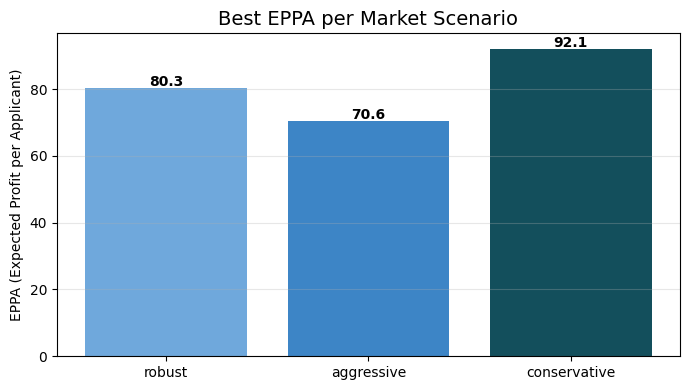

In [9]:
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

# === 1️⃣ 手动整理最优结果（从你刚才输出中提取） ===
summary_df = pd.DataFrame([
    {"scenario": "robust",        "c0": 0.025, "c1": 0.14, "pd_reject": 0.50, "kappa": 0.7, "EPPA_mean": 80.302, "EPPA_std": 0.100},
    {"scenario": "aggressive",    "c0": 0.025, "c1": 0.14, "pd_reject": 0.65, "kappa": 0.7, "EPPA_mean": 70.567, "EPPA_std": 0.000},
    {"scenario": "conservative",  "c0": 0.030, "c1": 0.14, "pd_reject": 0.70, "kappa": 0.7, "EPPA_mean": 92.109, "EPPA_std": 0.000},
])

# === 2️⃣ 打印 Markdown 表（可直接复制进报告 / Word / Notion） ===
markdown_table = tabulate(
    summary_df,
    headers="keys",
    tablefmt="github",
    floatfmt=".3f"
)
print("\n==== Markdown Table for Report ====\n")
print(markdown_table)

# === 3️⃣ 生成 LaTeX 表格（适合学术报告 / PDF） ===
latex_table = tabulate(
    summary_df,
    headers="keys",
    tablefmt="latex_booktabs",
    floatfmt=".3f"
)
print("\n==== LaTeX Table for Report ====\n")
print(latex_table)

# === 4️⃣ 生成简单条形图（报告插图用） ===
plt.figure(figsize=(7,4))
plt.bar(summary_df["scenario"], summary_df["EPPA_mean"], color=["#6FA8DC","#3D85C6","#134F5C"])
plt.title("Best EPPA per Market Scenario", fontsize=14)
plt.ylabel("EPPA (Expected Profit per Applicant)")
plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(summary_df["EPPA_mean"]):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


**Pricing Version 2: break-even + margin + varied preference cushion + rejection**

In [11]:
import numpy as np
import pandas as pd

# -----------------------------
# 7) Pricing rule (PD-dependent kappa)
# -----------------------------

def kappa_piecewise(pd_value):
    """
    Piecewise schedule for kappa(PD):
    - very low PD -> we dare to eat more of the preference cushion
    - higher PD -> we eat less
    You can tune these cut points and levels.
    """
    if pd_value < 0.03:
        return 0.80
    if pd_value < 0.07:
        return 0.60
    if pd_value < 0.12:
        return 0.40
    if pd_value < 0.20:
        return 0.25
    return 0.10

def kappa_linear(pd_value,
                 k_min=0.10, k_max=0.80,
                 pd_lo=0.00, pd_hi=0.20):
    """
    Linear decay in [pd_lo, pd_hi].
    PD <= pd_lo -> k_max
    PD >= pd_hi -> k_min
    """
    if pd_value <= pd_lo:
        return k_max
    if pd_value >= pd_hi:
        return k_min
    t = (pd_value - pd_lo) / (pd_hi - pd_lo)
    return float(k_max + (k_min - k_max) * t)

def kappa_sigmoid(pd_value,
                  k_min=0.10, k_max=0.80,
                  center=0.10, sharp=25.0):
    """
    Smooth S-shape: low PD -> near k_max, high PD -> near k_min.
    """
    s = 1.0 / (1.0 + np.exp(sharp * (pd_value - center)))
    return float(k_min + (k_max - k_min) * s)

def get_kappa(pd_value, mode="piecewise"):
    """
    Dispatcher to choose which kappa schedule family we are using.
    mode can be "piecewise", "linear", or "sigmoid".
    """
    if mode == "piecewise":
        return kappa_piecewise(pd_value)
    elif mode == "linear":
        return kappa_linear(pd_value)
    elif mode == "sigmoid":
        return kappa_sigmoid(pd_value)
    else:
        raise ValueError(f"Unknown kappa_mode '{mode}'")


def make_offer_rate_pdaware(
    pd_value,
    c0=0.02, c1=0.10,          # base margin + risk premium slope
    pd_reject=0.60,            # reject if PD >= this
    eps=0.00,                  # tiny randomization (0~0.02); keep 0 for eval
    pref_delta=0.02,           # 2% buyer preference advantage in rules
    pref_prob=1/3,             # ~1/3 of borrowers prefer us
    kappa_mode="piecewise"     # HOW kappa depends on PD
):
    """
    Return an offer rate for a given PD, using a PD-dependent kappa.

    Steps:
    - Reject (np.inf) if PD >= pd_reject.
    - Break-even rate r_break = PD / (1 - PD).
    - Margin = c0 + c1 * PD.
    - Preference cushion:
        kappa(PD) * pref_prob * pref_delta * (1 - PD)
      where kappa(PD) comes from kappa_mode.
    """
    if pd_value >= pd_reject:
        return np.inf

    # base economics
    r_break = pd_value / (1.0 - pd_value + 1e-12)
    margin  = c0 + c1 * pd_value

    # PD-aware kappa
    kappa_val = get_kappa(pd_value, mode=kappa_mode)

    pref_cushion = kappa_val * pref_prob * pref_delta * (1.0 - pd_value)

    r = r_break + margin + pref_cushion

    # small random jitter if requested
    if eps > 0:
        r *= (1.0 + np.random.uniform(-eps, eps))

    return r


# -----------------------------
# Vectorize pricing for our apps set
# -----------------------------
# assume apps already has columns: 'PD' and 'applicant_id'
OUT_PATH_PD_AWARE = "/kaggle/working/LoanOffers_Lender1_PDaware.csv"

apps['offer_rate_pdaware'] = apps['PD'].apply(
    lambda p: make_offer_rate_pdaware(
        p,
        c0=0.02, c1=0.10,
        pd_reject=0.60,
        eps=0.00,
        pref_delta=0.02,
        pref_prob=1/3,
        kappa_mode="piecewise"   # default schedule we evaluate
    )
)

# Safety: guard against negative or absurd values
apps.loc[apps['offer_rate_pdaware'] < 0, 'offer_rate_pdaware'] = 0.0

# -----------------------------
# Save offers
# -----------------------------
offers_pdaware = apps[['applicant_id', 'offer_rate_pdaware']].copy()
offers_pdaware.to_csv(OUT_PATH_PD_AWARE, index=False)
print(f"Saved PD-aware offers to: {OUT_PATH_PD_AWARE}")

# -----------------------------
# Quick summary
# -----------------------------
n_total = len(offers_pdaware)
n_reject = np.isinf(offers_pdaware['offer_rate_pdaware']).sum()
print(f"Total applicants: {n_total}")
print(f"Rejected (no offer): {n_reject} ({n_reject/n_total:.2%})")
print("Sample rows:")
print(offers_pdaware.head(10))


Saved PD-aware offers to: /kaggle/working/LoanOffers_Lender1_PDaware.csv
Total applicants: 100000
Rejected (no offer): 0 (0.00%)
Sample rows:
   applicant_id  offer_rate_pdaware
0             1            0.044805
1             2            0.146839
2             3            0.046983
3             4            0.114091
4             5            0.153031
5             6            0.205797
6             7            0.042473
7             8            0.490863
8             9            0.046753
9            10            0.179590


**EPPA Estimation**

In [12]:
# ================= EPPA evaluation helpers (same as before) =================
L = 10_000.0  # principal

def competitor_pricer_from_pd(pd_series, c0=0.02, c1=0.10, pd_reject=0.60):
    r_break = pd_series / (1.0 - pd_series)
    margin  = c0 + c1 * pd_series
    r = r_break + margin
    r = np.where(pd_series >= pd_reject, np.inf, r)
    return r

def _evaluate_core(df_apps, my_pricer, pd_col, seed, compA_params, compB_params, pref_bonus):
    rng = np.random.default_rng(seed)
    df = df_apps.copy()

    # 1) borrower preference draw
    n = len(df)
    df['borrower_type'] = rng.integers(low=1, high=4, size=n)

    # 2) competitor PDs from noisy version of our PD
    base_pd = df[pd_col].to_numpy().astype(float)

    def noisy_pd(base, sd):
        pd_hat = base + rng.normal(0.0, sd, size=base.shape)
        return np.clip(pd_hat, 0.001, 0.999)

    df['PD_compA'] = noisy_pd(base_pd, compA_params.get('noise_sd', 0.06))
    df['PD_compB'] = noisy_pd(base_pd, compB_params.get('noise_sd', 0.06))

    # 3) our offer using provided pricer
    my_rates = np.array([my_pricer(p) for p in base_pd])
    df['offer_me'] = my_rates

    # 4) competitor offers
    offer_A = competitor_pricer_from_pd(
        df['PD_compA'].values,
        c0=compA_params['c0'], c1=compA_params['c1'], pd_reject=compA_params['pd_reject']
    )
    offer_B = competitor_pricer_from_pd(
        df['PD_compB'].values,
        c0=compB_params['c0'], c1=compB_params['c1'], pd_reject=compB_params['pd_reject']
    )
    df['offer_A'] = offer_A
    df['offer_B'] = offer_B

    # 5) preference-adjusted effective rates
    eff_me = df['offer_me'].to_numpy().copy()
    eff_A  = df['offer_A'].to_numpy().copy()
    eff_B  = df['offer_B'].to_numpy().copy()

    eff_me = np.where(df['borrower_type'].to_numpy()==1, eff_me - pref_bonus, eff_me)
    eff_A  = np.where(df['borrower_type'].to_numpy()==2, eff_A  - pref_bonus, eff_A)
    eff_B  = np.where(df['borrower_type'].to_numpy()==3, eff_B  - pref_bonus, eff_B)

    # 6) winner = argmin effective rate
    eff_stack  = np.vstack([eff_me, eff_A, eff_B]).T
    winner_idx = np.argmin(eff_stack, axis=1)
    df['winner'] = winner_idx

    # 7) our realized expected profit
    win_mask = (winner_idx == 0) & np.isfinite(df['offer_me'].to_numpy())
    my_pd = base_pd
    my_r  = df['offer_me'].to_numpy()
    exp_profit_if_won = (1.0 - my_pd) * L * my_r - my_pd * L
    realized = np.where(win_mask, exp_profit_if_won, 0.0)

    # 8) EPPA
    eppa = realized.mean()

    offered = np.isfinite(df['offer_me'].to_numpy()).sum()
    won = win_mask.sum()
    take_rate = won / offered if offered > 0 else 0.0
    avg_profit_per_won = exp_profit_if_won[win_mask].mean() if won > 0 else 0.0

    summary = {
        "EPPA": float(eppa),
        "offered": int(offered),
        "won": int(won),
        "take_rate": float(take_rate),
        "avg_profit_per_won": float(avg_profit_per_won),
        "compA_params": compA_params,
        "compB_params": compB_params,
    }
    return eppa, summary


# ---- scenario wrappers (unchanged logic) ----
def evaluate_pricing_eppa_original(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    compA_params=dict(c0=0.018, c1=0.11, pd_reject=0.62, noise_sd=0.06),
    compB_params=dict(c0=0.022, c1=0.09, pd_reject=0.58, noise_sd=0.06),
    pref_bonus=0.02
):
    return _evaluate_core(df_apps, my_pricer, pd_col, seed, compA_params, compB_params, pref_bonus)

def evaluate_pricing_eppa_aggressive(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    comp_params=dict(c0=0.015, c1=0.09, pd_reject=0.70, noise_sd=0.06),
    pref_bonus=0.02
):
    return _evaluate_core(df_apps, my_pricer, pd_col, seed, comp_params, comp_params, pref_bonus)

def evaluate_pricing_eppa_neutral(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    comp_params=dict(c0=0.020, c1=0.10, pd_reject=0.60, noise_sd=0.06),
    pref_bonus=0.02
):
    return _evaluate_core(df_apps, my_pricer, pd_col, seed, comp_params, comp_params, pref_bonus)

def evaluate_pricing_eppa_conservative(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    comp_params=dict(c0=0.025, c1=0.11, pd_reject=0.55, noise_sd=0.06),
    pref_bonus=0.02
):
    return _evaluate_core(df_apps, my_pricer, pd_col, seed, comp_params, comp_params, pref_bonus)

def evaluate_pricing_eppa_robust(
    df_apps,
    my_pricer,
    pd_col="PD",
    seed=20251016,
    pref_bonus=0.02
):
    e_aggr, s_aggr = evaluate_pricing_eppa_aggressive(
        df_apps, my_pricer, pd_col=pd_col, seed=seed, pref_bonus=pref_bonus
    )
    e_neut, s_neut = evaluate_pricing_eppa_neutral(
        df_apps, my_pricer, pd_col=pd_col, seed=seed, pref_bonus=pref_bonus
    )
    e_cons, s_cons = evaluate_pricing_eppa_conservative(
        df_apps, my_pricer, pd_col=pd_col, seed=seed, pref_bonus=pref_bonus
    )

    eppa_values = np.array([e_aggr, e_neut, e_cons], dtype=float)
    eppa_mean = float(eppa_values.mean())
    eppa_std  = float(eppa_values.std(ddof=0))

    summary = {
        "EPPA_mean": eppa_mean,
        "EPPA_std": eppa_std,
        "scenarios": {
            "aggressive": s_aggr,
            "neutral": s_neut,
            "conservative": s_cons
        }
    }
    return eppa_mean, summary


# -----------------------------
# 11) Evaluate EPPA using PD-aware pricing
# -----------------------------
def my_pricer_for_eval_pdaware(pd_value):
    return make_offer_rate_pdaware(
        pd_value,
        c0=0.02, c1=0.10,
        pd_reject=0.60,
        eps=0.00,           # keep stable for evaluation
        pref_delta=0.02,
        pref_prob=1/3,
        kappa_mode="piecewise"   # choose which PD→kappa schedule to test
    )

SEED = 20251016

e_orig_pdaware, s_orig_pdaware = evaluate_pricing_eppa_original(apps, my_pricer_for_eval_pdaware, pd_col="PD", seed=SEED)
e_aggr_pdaware, s_aggr_pdaware = evaluate_pricing_eppa_aggressive(apps, my_pricer_for_eval_pdaware, pd_col="PD", seed=SEED)
e_neut_pdaware, s_neut_pdaware = evaluate_pricing_eppa_neutral(apps, my_pricer_for_eval_pdaware, pd_col="PD", seed=SEED)
e_cons_pdaware, s_cons_pdaware = evaluate_pricing_eppa_conservative(apps, my_pricer_for_eval_pdaware, pd_col="PD", seed=SEED)
e_rob_pdaware, s_rob_pdaware   = evaluate_pricing_eppa_robust(apps, my_pricer_for_eval_pdaware, pd_col="PD", seed=SEED)

print("\n==== EPPA by Market Scenario (PD-aware kappa) ====")
print(f"Original (mixed)      | EPPA = {e_orig_pdaware:.4f} | take_rate = {s_orig_pdaware['take_rate']:.2%} | avg_profit_per_won = {s_orig_pdaware['avg_profit_per_won']:.2f}")
print(f"Aggressive (both)     | EPPA = {e_aggr_pdaware:.4f} | take_rate = {s_aggr_pdaware['take_rate']:.2%} | avg_profit_per_won = {s_aggr_pdaware['avg_profit_per_won']:.2f}")
print(f"Neutral (both)        | EPPA = {e_neut_pdaware:.4f} | take_rate = {s_neut_pdaware['take_rate']:.2%} | avg_profit_per_won = {s_neut_pdaware['avg_profit_per_won']:.2f}")
print(f"Conservative (both)   | EPPA = {e_cons_pdaware:.4f} | take_rate = {s_cons_pdaware['take_rate']:.2%} | avg_profit_per_won = {s_cons_pdaware['avg_profit_per_won']:.2f}")

print("\n==== Robust EPPA (mean of 3 scenarios) ====")
print(f"Robust EPPA (mean) = {e_rob_pdaware:.4f} | std = {s_rob_pdaware['EPPA_std']:.4f}")
print("Details:", s_rob_pdaware['scenarios'])

summary_rows_pdaware = [
    ("original",      e_orig_pdaware, s_orig_pdaware["take_rate"], s_orig_pdaware["avg_profit_per_won"]),
    ("aggressive",    e_aggr_pdaware, s_aggr_pdaware["take_rate"], s_aggr_pdaware["avg_profit_per_won"]),
    ("neutral",       e_neut_pdaware, s_neut_pdaware["take_rate"], s_neut_pdaware["avg_profit_per_won"]),
    ("conservative",  e_cons_pdaware, s_cons_pdaware["take_rate"], s_cons_pdaware["avg_profit_per_won"]),
    ("robust_mean",   e_rob_pdaware,  None,                           None),
]
summary_df_pdaware = pd.DataFrame(summary_rows_pdaware, columns=["scenario", "EPPA", "take_rate", "avg_profit_per_won"])
print("\n==== Summary Table (PD-aware kappa) ====")
print(summary_df_pdaware)



==== EPPA by Market Scenario (PD-aware kappa) ====
Original (mixed)      | EPPA = 75.2146 | take_rate = 25.98% | avg_profit_per_won = 289.53
Aggressive (both)     | EPPA = 66.7244 | take_rate = 23.05% | avg_profit_per_won = 289.48
Neutral (both)        | EPPA = 74.9822 | take_rate = 25.89% | avg_profit_per_won = 289.65
Conservative (both)   | EPPA = 86.3968 | take_rate = 29.93% | avg_profit_per_won = 288.70

==== Robust EPPA (mean of 3 scenarios) ====
Robust EPPA (mean) = 76.0345 | std = 8.0656
Details: {'aggressive': {'EPPA': 66.72443931193224, 'offered': 100000, 'won': 23050, 'take_rate': 0.2305, 'avg_profit_per_won': 289.4769601385347, 'compA_params': {'c0': 0.015, 'c1': 0.09, 'pd_reject': 0.7, 'noise_sd': 0.06}, 'compB_params': {'c0': 0.015, 'c1': 0.09, 'pd_reject': 0.7, 'noise_sd': 0.06}}, 'neutral': {'EPPA': 74.98221875748365, 'offered': 100000, 'won': 25887, 'take_rate': 0.25887, 'avg_profit_per_won': 289.65202131372365, 'compA_params': {'c0': 0.02, 'c1': 0.1, 'pd_reject': 0.6,

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


**Grid search for kappa mode**

In [13]:
import itertools
import numpy as np
import pandas as pd

# Map scenario name -> evaluator
EVAL_MAP_PD_AWARE = {
    "original":     evaluate_pricing_eppa_original,
    "aggressive":   evaluate_pricing_eppa_aggressive,
    "neutral":      evaluate_pricing_eppa_neutral,
    "conservative": evaluate_pricing_eppa_conservative,
    "robust":       evaluate_pricing_eppa_robust,
}

def _build_pricer_from_params_pdaware(
    c0, c1, pd_reject,
    kappa_mode,
    eps=0.0,
    pref_delta=0.02,
    pref_prob=1/3
):
    """
    Returns a callable pricer(pd_value) that uses PD-aware kappa.
    """
    def _pricer(pd_value):
        return make_offer_rate_pdaware(
            pd_value,
            c0=c0, c1=c1,
            pd_reject=pd_reject,
            eps=eps,
            pref_delta=pref_delta,
            pref_prob=pref_prob,
            kappa_mode=kappa_mode
        )
    return _pricer


def grid_search_pricing_pdaware(
    df_apps,
    param_grid,
    scenario="robust",
    seeds=(20251016,),
    pd_col="PD",
    pref_delta=0.02,
    pref_prob=1/3,
    top_k=15,
    verbose=True
):
    """
    param_grid example:
        param_grid = {
            "c0":         [0.015, 0.02, 0.025],
            "c1":         [0.08, 0.10, 0.12],
            "pd_reject":  [0.55, 0.60, 0.65],
            "kappa_mode": ["piecewise","linear","sigmoid"],
            # "eps":      [0.0]
        }
    """
    if scenario not in EVAL_MAP_PD_AWARE:
        raise ValueError(f"Unknown scenario '{scenario}'. Valid: {list(EVAL_MAP_PD_AWARE.keys())}")

    eval_fn = EVAL_MAP_PD_AWARE[scenario]

    keys = ["c0", "c1", "pd_reject", "kappa_mode", "eps"]
    grid = {
        k: (param_grid[k] if k in param_grid else ([0.0] if k=="eps" else None))
        for k in keys
    }
    for k in ["c0", "c1", "pd_reject", "kappa_mode"]:
        if grid[k] is None:
            raise ValueError(f"param_grid missing key '{k}'")

    combos = list(itertools.product(
        grid["c0"],
        grid["c1"],
        grid["pd_reject"],
        grid["kappa_mode"],
        grid["eps"]
    ))

    rows = []
    for (c0, c1, pd_reject, kappa_mode, eps) in combos:
        my_pricer = _build_pricer_from_params_pdaware(
            c0=c0, c1=c1,
            pd_reject=pd_reject,
            kappa_mode=kappa_mode,
            eps=eps,
            pref_delta=pref_delta,
            pref_prob=pref_prob
        )

        eppa_list = []
        take_rate_list = []
        avg_profit_won_list = []

        for sd in seeds:
            eppa, summary = eval_fn(
                df_apps,
                my_pricer,
                pd_col=pd_col,
                seed=sd,
                pref_bonus=pref_delta
            )

            eppa_list.append(float(eppa))
            if isinstance(summary, dict):
                if "take_rate" in summary:
                    take_rate_list.append(summary["take_rate"])
                if "avg_profit_per_won" in summary:
                    avg_profit_won_list.append(summary["avg_profit_per_won"])

        eppa_mean = float(np.mean(eppa_list))
        eppa_std  = float(np.std(eppa_list, ddof=0))

        take_rate_mean = float(np.mean(take_rate_list)) if take_rate_list else np.nan
        avg_profit_won_mean = float(np.mean(avg_profit_won_list)) if avg_profit_won_list else np.nan

        rows.append({
            "scenario": scenario,
            "seeds": len(seeds),
            "c0": c0,
            "c1": c1,
            "pd_reject": pd_reject,
            "kappa_mode": kappa_mode,
            "eps": eps,
            "EPPA_mean": eppa_mean,
            "EPPA_std": eppa_std,
            "take_rate_mean": take_rate_mean,
            "avg_profit_per_won_mean": avg_profit_won_mean
        })

    results_df = pd.DataFrame(rows).sort_values("EPPA_mean", ascending=False).reset_index(drop=True)

    if verbose:
        print(f"\n==== Grid Search (PD-aware kappa) | scenario={scenario} | seeds={list(seeds)} ====")
        display_cols = [
            "EPPA_mean", "EPPA_std",
            "c0", "c1", "pd_reject", "kappa_mode", "eps",
            "take_rate_mean", "avg_profit_per_won_mean"
        ]
        print(results_df[display_cols].head(top_k))

    return results_df


**Grid search for parameters**

In [14]:
# ======================== Run Grid Search Across Scenarios (PD-aware) ========================

param_grid_pdaware = {
    "c0":         [0.01, 0.015, 0.02, 0.025, 0.03],
    "c1":         [0.06, 0.08, 0.10, 0.12, 0.14],
    "pd_reject":  [0.50, 0.55, 0.60, 0.65, 0.70],
    "kappa_mode": ["piecewise", "linear", "sigmoid"],
    # "eps":      [0.0],  # can omit, default 0.0
}

# 1) Robust market
res_robust_pdaware = grid_search_pricing_pdaware(
    apps,
    param_grid_pdaware,
    scenario="robust",
    seeds=(20251016, 20251017, 20251018),
    pd_col="PD",
    top_k=10
)

# 2) Aggressive market
res_aggr_pdaware = grid_search_pricing_pdaware(
    apps,
    param_grid_pdaware,
    scenario="aggressive",
    seeds=(20251016,),
    pd_col="PD",
    top_k=10
)

# 3) Conservative market
res_cons_pdaware = grid_search_pricing_pdaware(
    apps,
    param_grid_pdaware,
    scenario="conservative",
    seeds=(20251016,),
    pd_col="PD",
    top_k=10
)

# 4) Neutral market
res_neut_pdaware = grid_search_pricing_pdaware(
    apps,
    param_grid_pdaware,
    scenario="neutral",
    seeds=(20251016,),
    pd_col="PD",
    top_k=10
)

# 5) Collect best rows per scenario
scenarios_pdaware = ["aggressive", "neutral", "conservative", "original", "robust"]

results_summary_pdaware = []

for sc in scenarios_pdaware:
    print(f"\n\n>>> Running grid search (PD-aware kappa) for scenario: {sc.upper()} <<<")
    res_tmp = grid_search_pricing_pdaware(
        apps,
        param_grid_pdaware,
        scenario=sc,
        seeds=(20251016, 20251017),
        pd_col="PD",
        top_k=5
    )
    best_row = res_tmp.iloc[0].to_dict()
    results_summary_pdaware.append({
        "scenario": sc,
        "EPPA_mean": best_row["EPPA_mean"],
        "EPPA_std": best_row["EPPA_std"],
        "c0": best_row["c0"],
        "c1": best_row["c1"],
        "pd_reject": best_row["pd_reject"],
        "kappa_mode": best_row["kappa_mode"]
    })

summary_df_pdaware_best = pd.DataFrame(results_summary_pdaware)
print("\n==== Best Parameter Combination per Market Scenario (PD-aware kappa) ====")
print(summary_df_pdaware_best)



==== Grid Search (PD-aware kappa) | scenario=robust | seeds=[20251016, 20251017, 20251018] ====
   EPPA_mean  EPPA_std    c0    c1  pd_reject kappa_mode  eps  take_rate_mean  \
0  80.256880  0.077845  0.03  0.12       0.60    sigmoid  0.0             NaN   
1  80.256880  0.077845  0.03  0.12       0.70    sigmoid  0.0             NaN   
2  80.256880  0.077845  0.03  0.12       0.55    sigmoid  0.0             NaN   
3  80.256880  0.077845  0.03  0.12       0.65    sigmoid  0.0             NaN   
4  80.256880  0.077845  0.03  0.12       0.50    sigmoid  0.0             NaN   
5  80.199887  0.055036  0.03  0.14       0.55     linear  0.0             NaN   
6  80.199887  0.055036  0.03  0.14       0.70     linear  0.0             NaN   
7  80.199887  0.055036  0.03  0.14       0.65     linear  0.0             NaN   
8  80.199887  0.055036  0.03  0.14       0.50     linear  0.0             NaN   
9  80.199887  0.055036  0.03  0.14       0.60     linear  0.0             NaN   

   avg_prof

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()



==== Grid Search (PD-aware kappa) | scenario=aggressive | seeds=[20251016] ====
   EPPA_mean  EPPA_std     c0    c1  pd_reject kappa_mode  eps  \
0  70.751122       0.0  0.025  0.14       0.70     linear  0.0   
1  70.751122       0.0  0.025  0.14       0.50     linear  0.0   
2  70.751122       0.0  0.025  0.14       0.65     linear  0.0   
3  70.751122       0.0  0.025  0.14       0.55     linear  0.0   
4  70.751122       0.0  0.025  0.14       0.60     linear  0.0   
5  70.668552       0.0  0.025  0.14       0.50    sigmoid  0.0   
6  70.668552       0.0  0.025  0.14       0.70    sigmoid  0.0   
7  70.668552       0.0  0.025  0.14       0.65    sigmoid  0.0   
8  70.668552       0.0  0.025  0.14       0.55    sigmoid  0.0   
9  70.668552       0.0  0.025  0.14       0.60    sigmoid  0.0   

   take_rate_mean  avg_profit_per_won_mean  
0         0.19369               365.280199  
1         0.19369               365.280199  
2         0.19369               365.280199  
3         0.

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


**Plots**


==== Markdown Table for Report (PD-aware kappa) ====

|    | scenario     |    c0 |    c1 |   pd_reject | kappa_mode   |   EPPA_mean |   EPPA_std |
|----|--------------|-------|-------|-------------|--------------|-------------|------------|
|  0 | robust       | 0.025 | 0.140 |       0.500 | piecewise    |      80.302 |      0.100 |
|  1 | aggressive   | 0.025 | 0.140 |       0.650 | sigmoid      |      70.567 |      0.000 |
|  2 | conservative | 0.030 | 0.140 |       0.700 | linear       |      92.109 |      0.000 |

==== LaTeX Table for Report (PD-aware kappa) ====

\begin{tabular}{rlrrrlrr}
\toprule
    & scenario     &    c0 &    c1 &   pd\_reject & kappa\_mode   &   EPPA\_mean &   EPPA\_std \\
\midrule
  0 & robust       & 0.025 & 0.140 &       0.500 & piecewise    &      80.302 &      0.100 \\
  1 & aggressive   & 0.025 & 0.140 &       0.650 & sigmoid      &      70.567 &      0.000 \\
  2 & conservative & 0.030 & 0.140 &       0.700 & linear       &      92.109 &      0.000 \\

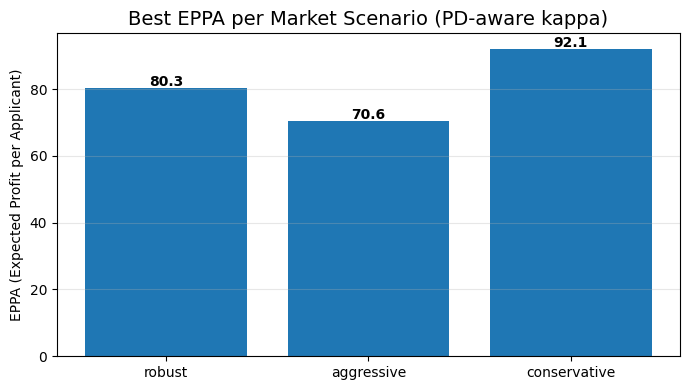

In [15]:
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

# 假设你把 summary_df_pdaware_best 里最好的行手动挑出来，像下面这样填：
summary_df_pdaware_best = pd.DataFrame([
    {"scenario": "robust",        "c0": 0.025, "c1": 0.14, "pd_reject": 0.50, "kappa_mode": "piecewise", "EPPA_mean": 80.302, "EPPA_std": 0.100},
    {"scenario": "aggressive",    "c0": 0.025, "c1": 0.14, "pd_reject": 0.65, "kappa_mode": "sigmoid",   "EPPA_mean": 70.567, "EPPA_std": 0.000},
    {"scenario": "conservative",  "c0": 0.030, "c1": 0.14, "pd_reject": 0.70, "kappa_mode": "linear",    "EPPA_mean": 92.109, "EPPA_std": 0.000},
])

# 1) Markdown table
markdown_table_pdaware = tabulate(
    summary_df_pdaware_best,
    headers="keys",
    tablefmt="github",
    floatfmt=".3f"
)
print("\n==== Markdown Table for Report (PD-aware kappa) ====\n")
print(markdown_table_pdaware)

# 2) LaTeX table
latex_table_pdaware = tabulate(
    summary_df_pdaware_best,
    headers="keys",
    tablefmt="latex_booktabs",
    floatfmt=".3f"
)
print("\n==== LaTeX Table for Report (PD-aware kappa) ====\n")
print(latex_table_pdaware)

# 3) Simple bar chart for EPPA
plt.figure(figsize=(7,4))
plt.bar(summary_df_pdaware_best["scenario"], summary_df_pdaware_best["EPPA_mean"])
plt.title("Best EPPA per Market Scenario (PD-aware kappa)", fontsize=14)
plt.ylabel("EPPA (Expected Profit per Applicant)")
plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(summary_df_pdaware_best["EPPA_mean"]):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()
